<table>
    <tr>
        <td><img src="https://s3.amazonaws.com/media-p.slid.es/uploads/1485763/images/9060062/Header.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:#6A0DAD;text-align:center"> <FONT COLOR="#6A0DAD"> Modelos de Regresión</FONT> </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Sesión 5</p></tp>
            <tp><p style="font-size:115%;text-align:center">11 de Abril 2026</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Daniel Rambaut </p></tp>
        </td>
    </tr>
</table>

En este notebook profundizaremos en el mundo de la **Regresión**. A diferencia de las sesiones anteriores donde buscábamos predecir categorías o etiquetas (clasificación), aquí nuestro objetivo será predecir **valores numéricos continuos** (como precios, temperaturas o ventas).
<br>
Aprenderemos sobre:
- la **Regresión Lineal Simple** (usando una sola variable para predecir)
- la **Regresión Lineal Múltiple** (usando múltiples variables)
- Cómo el modelo matemáticamente encuentra la mejor línea de predicción mediante **"Mínimos Cuadrados"**.
- Cómo evaluar qué tan buenas son nuestras predicciones usando métricas como el **Error Cuadrático Medio** (MSE) y el $R^2$.

---
# <FONT SIZE=5 COLOR="green"> 0. Repaso de la sesión anterior </FONT>

En la sesión pasada exploramos una de las herramientas más intuitivas y poderosas para clasificar datos: los **Árboles de Decisión**. Los conceptos clave fueron:

<FONT COLOR="green" SIZE=3>1. Árboles de Decisión:</FONT>  
Son modelos que toman decisiones basadas en reglas condicionales simples (como preguntas de "sí o no"), dividiendo los datos sucesivamente hasta llegar a una predicción final (hoja). Son excelentes porque son muy fáciles de interpretar.

<FONT COLOR="green" SIZE=3>2. Sobreajuste y Poda (Pruning):</FONT>
<br>
Vimos que si dejamos crecer un árbol sin límites, este termina "memorizando" los datos de entrenamiento (sobreajuste o *overfitting*), volviéndose incapaz de predecir casos nuevos. Para evitarlo, usamos la **poda**, que es como cortar las ramas innecesarias del árbol.

<FONT COLOR="green" SIZE=3>3. Pre-poda y Post-poda (CCP):</FONT>
<br>
La *pre-poda* restringe el crecimiento del árbol desde el principio (limitando su profundidad). La *post-poda* (usando el método CCP - Cost Complexity Pruning) deja que el árbol crezca por completo y luego elimina analíticamente las ramas que no aportan valor real a la predicción, encontrando el árbol óptimo.

---

# <FONT SIZE=5 COLOR="purple"> 1. Introducción </FONT>

**Modelo de regresión:** es el modelo en el que se busca establecer la relación entre un cierto número de características y una variable objetivo continua. Es decir, la relación entre la variable dependiente $y$ y las variables predictoras $x_1, x_2 , \dots , x_n$.



A continuación, definiremos las librerías necesarias para trabajar regresión

In [16]:
# Para gráficos y data.frames
import pandas as pd
import numpy  as np

# librerías para graficar
import plotly.express     as px
import matplotlib.pyplot  as plt
import seaborn            as sns


# Dividir los datos entrenamiento y prueba
from sklearn.model_selection     import train_test_split
from sklearn.feature_selection   import RFE

# Para preprocesamiento: escalador
from sklearn.preprocessing       import StandardScaler

# Modelo de regresión
from sklearn.linear_model        import LinearRegression
from sklearn.svm                 import SVR
from sklearn.neighbors           import KNeighborsRegressor
from sklearn.tree                import DecisionTreeRegressor
from sklearn.ensemble            import RandomForestRegressor

# Métricas
from sklearn                     import metrics
from sklearn.metrics             import mean_squared_error, r2_score

# warnings
import warnings
warnings.filterwarnings('ignore')

# <FONT SIZE=5 COLOR="purple"> 2. Conceptos básicos de Machine Learning: Regresión </FONT>

En está sección revisaremos algunos conceptos básicos de regresión en  machine learning.

<FONT SIZE=3 COLOR="green"> a. Algoritmos de regresión: </FONT>  técnicas de aprendizaje supervisado para hacer predicciones sobre una variable objetivo $\mathbf{y}$ que es numérica continua, es decir, toma valor en un intervalo.


<center><FONT SIZE=4 COLOR="BLUE">Situación 1: Predicción ventas </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/ef2f70be5b4059198fa6d856ae1ad0b9802960df/supervisado4.png?raw=true" alt="centered image" width="500" height="250"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><FONT SIZE=4 COLOR="BLUE">Situación 2: Predicción precio apartamento </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/34ca9d1b545bc223a6505754189ac5499fdbc560/intro_regresion_1.jpg?raw=true" alt="centered image" width="500" height="250"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=3 COLOR="green"> b. Variable Objetivo: </FONT> también denominada **variable de respuesta**. En un algoritmo de aprendizaje de máquina supervisado, es la variable que queremos predecir (por lo general, denotada como $\mathbf{y}$).
<br>

<FONT SIZE=3 COLOR="green"> c. Variable(s) Predictora(s): </FONT> también denominada ***features*** o características, son las variables que se usarán para predecir la variable objetivo. Estas se denotan como

$$\mathbf{X}=\{X_1,X_2, \dots, X_n \}$$

<br>

<FONT SIZE=3 COLOR="green"> d. Conjunto de Entrenamiento: </FONT> es el subconjunto de registros que se selecciona para entrenar el modelo. Este conjunto consta de dos partes:

- $X_{train}$ : conjunto de entrenamiento de los predictores o *features*.

- $y_{train}$: conjunto de entrenamiento de la variable objetivo asociada al conjunto $X_{train}$.

El conjunto de entrenamiento se selecciona de manera aleatoria y por lo general se toma el $70\%$ , $75\%$ y $80 \%$.

<br>

<FONT SIZE=3 COLOR="green"> e. Conjunto de Prueba: </FONT>: Es el subconjunto de registros que se selecciona para validar el modelo. Consta de dos partes:

- $X_{test}$ : conjunto de validación de los predictores o *features*.

- $y_{test}$: conjunto de validación de la variable objetivo asociada al conjunto $X_{test}$.

El tamaño de este conjunto es el complemento del conjunto de entrenamiento.

**Nota:** para algoritmos clásicos de machine learning se acostumbra dividir en entrenamiento y prueba. Sin embargo, en algoritmos más complejos que requieren el entrenamiento de mucho parámetros, como es el caso de las redes neuronales, se acostumbra dividir en tres partes: *train* , *validation* and *test*.

<center><FONT SIZE=4 COLOR="BLUE"> Esquema general de modelos supervisados en Machine Learning </FONT></center>

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/209c0394fc9518a5c7331d550d5606bf355c5707/esquema_modelos.jpg?raw=true" alt="centered image" width="700" height="500"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


<FONT SIZE=4 COLOR="blue"> Algunos modelos de regresión </FONT>

Dentro de la bateria de modelos usados para regresión tenemos

1. Regresión lineal simple.

2. Regresión lineal múltiple

3. knn (k-vecinos más cercanos)

4. Árboles de Decisión

5. SVR: máquina de vectores de soporte para regresión

6. Random Forest


## <FONT SIZE=4 COLOR="blue"> 2.1. Ejercicios — Conceptos Básicos </FONT>


### <FONT SIZE=3 COLOR="blue"> Ejercicio 1 </FONT>
Imagina que trabajas para una empresa de retail. Da un ejemplo de un problema de negocio que se resolvería con Clasificación y otro problema que se resolvería con Regresión. Justifica tu respuesta entendiendo la diferencia en la "Variable Objetivo".


*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
En el sector inmobiliario, si queremos predecir el precio de alquiler de una oficina, lista al menos 4 variables que considerarías como "Variables Predictoras ($X$)". ¿Por qué crees que son importantes para definir el valor objetivo ($y$)?


*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="blue"> Ejercicio 3 </FONT>
A lo largo de este notebook usaremos un dataset de apartamentos. Tu tarea es cargar este dataset (que dejaremos en la variable `url`), visualizar las primeras 5 filas y mostrar el tipo de datos de cada columna para identificar nuestras posibles variables predictoras numéricas.

In [41]:
# URL del dataset de prueba
url = "https://raw.githubusercontent.com/drambaut/APRENDIZAJE-AUTOMATICO-DE-MAQUINA-I-/refs/heads/main/datasets/Apartamentos.csv"

# TU CÓDIGO AQUÍ
# 1. Carga los datos usando pd.read_csv()
aptos = ...
# 2. Muestra las primeras 5 filas
# 3. Usa el método .dtypes o .info() para ver los tipos de variables

,Unnamed: 0,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,1,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,2,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,3,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,4,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,5,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


# <FONT SIZE=5 COLOR="purple"> 3. Modelo de Regresión Lineal Simple </FONT>

En este notebook iniciaremos explicando cómo funciona el modelo de **regresión lineal simple**, para ellos daremos una introducción a dos conceptos muy usados:
**covarianza** y **coeficiente de correlación**.









## <FONT SIZE=4 COLOR="green"> 3.1 Covarianza </FONT>

La covarianza es el valor que refleja en que medida dos variables aleatorias varian de forma conjunta respecto a sus medias.

De acuerdo con lo anterior, la covarianza está dada por la siguiente fórmula

$$Muestra: Cov(X,Y)=S_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{n-1}$$

$$Poblacion:COV(X,Y)=\sigma_{XY}=\dfrac{\sum \limits_{i=1}^N (x_i-\mu_x)(y_i-\mu_y)}{N}$$

donde $\overline{x}$ y $\overline{y}$ son las medias de las variables $X$ y $Y$ respectivamente y $n$ es el total de observaciones.

A continuación listaremos algunas propiedades de la covarianza

- $Cov(X,c)=0$, donde $c$ es una constante.

- $Cov(X,X)=Var(X)$, la covarianza de una variable con si misma es la varianza de la variable.

- $Cov(X,Y)=Cov(Y,X)$, la varianza es simétrica, es decir, no importa el orden en que se coloquen la variables.

- La covarianza mide la fuerza de la relación lineal entre dos variables.

- Una alta covarianza no implica efecto causal.

**Interpretación de la covarianza**

- $Cov(X,Y)>0$ ; las variables $X$ y $Y$ tienden a moverse en la misma dirección.

- $Cov(X,Y)<0$   las variables $X$ y $Y$ tienden a moverse en direcciones opuestas.

- $Cov(X,Y)=0$: las variables $X$ y $Y$ no estan relacionadas linealmente.

<br>
<center><img src="https://virtual.uptc.edu.co/ova/estadistica/docs/libros/ftp.bioestadistica.uma.es/libro/img456.gif" alt="centered image" width="600" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://virtual.uptc.edu.co/ova/estadistica/docs/libros/ftp.bioestadistica.uma.es/libro/node38.htm</FONT> <figcaption></center>
<br>

## <FONT SIZE=4 COLOR="green"> 3.2 Coeficiente de Correlación </FONT>

El coeficiente de correlación se define como

$$muestra: r_{xy}=\dfrac{S_{xy}}{S_xS_y} \qquad \qquad poblacion : \rho_{xy}=\dfrac{\sigma_{xy}}{\sigma_{x}\sigma_{y}}$$

lo que es equivalente a

$$r_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{\left (\sum \limits_{i=1}^n (x_i-\overline{x})^2 \right)^{1/2} \left ( \sum \limits_{i=1}^n (y_i-\overline{y})^2 \right)^{1/2}}$$

Veamos la interpretación de los diferentes valores del coeficiente de correlación de Pearson, teniendo en cuenta que:

$$-1 \leq r_{xy} \leq 1 $$

- Si $r_{xy}=1$, hay una relación positiva perfecta, es decir, indica una dependencia total entre las variables de manera directa. Si una de ellas aumenta, la otra también lo hace en proporción constante. Es decir, la relación es lineal.

- Si $0<r_{x,y}<1$, existe una correlación positiva.

- Si $r_{x,y}=0$, no existe relación lineal. Pero pueden haber otro tipo de relaciones.

- Si $-1<r_{x,y}<0$, existe una correlación negativa.

- Si $r_{x,y}=-1$, existe una correlación negativa perfecta, es decir, indica una dependencia total de manera inversa. Si una variable disminuye la otra aumenta en proporción constante.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/da5b836cf8bee14fa8ca4ffa3e53dd97c41136ea/regresi%C3%B3n4.png?raw=true" alt="centered image" width="800" height="800"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<br>
<center><img src="https://static.platzi.com/media/user_upload/tablita-5e6d38e8-8b72-4f20-9c17-8bfa7e11259b.jpg" alt="centered image" width="500" height="250"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://platzi.com/blog/coeficiente-de-correlacion-que-es-y-para-que-sirve/  </FONT> <figcaption></center>
<br>

Algunas propiedades para tener en cuenta del coeficiente de correlación:

- No depende de las unidades de las variables.

- El coefiente de Pearson es acotado





## <FONT SIZE=4 COLOR="green"> 3.3 Modelo de regresión lineal simple </FONT>

Supongamos que tenemos dos variables cuantitativas, que representan en el plano un conjunto de puntos $(x,y)$. En general, estos puntos no tienen porque estar ajustados de forma lineal, es decir, el diagrama de dispersión no tiene porque representar una recta.

Sin embargo, existen situaciones en que los puntos se aproximan o se ajustan en mayor medida a una línea recta. Particualmente cuando el coeficiente de correlación es cercano a 1 o a -1.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/regresion1.png?raw=true" alt="centered image" width="550" height="300"></center>
<br>

La idea es encontrar una recta que se aproxime a los puntos dados

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/regresion2.png?raw=true" alt="centered image" width="550" height="300"></center>
<br>

Para hallar la ecuación de la recta que se observa en el gráfico se puede usar:

- Método de los mínimos cuadrados.

- Descenso del gradiente

<FONT SIZE=4 COLOR="blue"> Mínimos Cuadrados </FONT>

El método de los mínimos cuadrados permite hacer una estimación del modelo de regresión lineal simple.

Buscamos una recta de la forma

$$\hat{y}= \hat{\beta_0}+\hat{\beta_1}x$$

El método de mínimos cuadrados consiste en minimizar las sumas de los cuadrados de los errores $(SSE)$:

$$SSE=\sum \limits_{i=1}^n e_{i}^2= \sum \limits_{i=1}^n (y_{i}-\hat{y_i})^2$$

Esta expresión es la suma de las distancias al cuadrado entre los valores $y_i$ de la muestra (conjunto de datos) y los valores ajustados $\hat{y_i}$.

$$SSE(\hat{\beta_0},\hat{\beta_1})=\sum \limits_{i=1}^n (y_{i}-\hat{\beta_0}-\hat{\beta_1}x_i)^2$$

El objetivo de los mínimos cuadrados es hallar los valores de $\hat{\beta}_0$ y $\hat{\beta}_1$ que minimicen la expresión anterior. Para esto, realizaremos el procedimiento clásico para minimizar una función de dos variables y por tanto, derivamos parcialmente con respecto a los parámetros $\hat{\beta_0}$ y $\hat{\beta_1}$ e igualamos a cero.

$$\dfrac{\partial (SSE)}{\partial \hat{\beta}_0} = -2 \sum \limits_{i=1}^n (y_{i}-\hat{\beta}_0-\hat{\beta}_1x_i)$$
$$ \dfrac{\partial (SSE)}{\partial \hat{\beta_1}} = -2 \sum \limits_{i=1}^n (y_{i}-\hat{\beta_0}-\hat{\beta_1}x_i)x_i$$

el procedimiento que sigue se le deja al lector. Al igualar a cero y despejar $\hat{\beta_0}$ y $\hat{\beta_1}$ se obtiene:

$$\hat{\beta_0}= \dfrac{\sum \limits_{i=1}^n y_i - \hat{\beta}_1 \sum \limits_{i=1}^n x_i}{n}=\overline{y}-\hat{\beta_1}\overline{x} $$
$$\hat{\beta_1}=\dfrac{\sum \limits_{i=1}^n (x_i- \overline{x})(y_i-\overline{y})}{\sum \limits_{i=1}^n(x_i -\overline{x})^2}= \dfrac{S_{xy}}{S_{xx}}$$


donde, $S_{xy}$ es la covarianza muestral entre $X$ y $Y$.





## <FONT SIZE=4 COLOR="blue"> 3.3.1 Ejercicios — Covarianza, Correlación y Mínimos Cuadrados </FONT>


### <FONT SIZE=3 COLOR="blue"> Ejercicio 1</FONT>
Si calculamos el coeficiente de correlación de Pearson entre los metros cuadrados $mt^2$ de un apartamento y su `precio`, y obtenemos un valor de 0.85, ¿Cómo le explicarías este resultado a un cliente que no sabe de estadística?


*Escribe tu respuesta aquí:*



### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
La fórmula de "Mínimos Cuadrados" puede verse compleja, pero su propósito es sencillo. En tus propias palabras, ¿Qué es exactamente el "error" que esta fórmula está tratando de hacer lo más pequeño posible? (Piensa en la relación entre los puntos reales y la línea que dibujamos).


*Escribe tu respuesta aquí:*


## <FONT SIZE=5 COLOR="purple"> 3.4 Evaluación de un modelo de regresión </FONT>

En esta sección revisaremos la forma en que se evalúa un modelo de regresión.

***MSE : Error cuadrático medio***

Matemáticamente, el $MSE$ se puede calcular como la suma promedio de la diferencia al cuadrado entre el valor real y el valor previsto o estimado representado por el modelo de regresión (línea o plano).

![picture](https://drive.google.com/uc?id=1-ECWZXb0YaYDNx-tb5DP6C44nlSrzLZu)


***$R^2$ coeficiente de determinación***

$R^2$ es la relación entre la regresión de suma de cuadrados (SSR) y la suma de cuadrados total (SST).

$$R^2 = \dfrac{SSR}{SST}= \dfrac{\sum \limits_{i=1}^{n} (\hat{y_i}-\overline{y})^2}{\sum \limits_{i=1}^{n} (y_i - \overline{y})^2}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/f8b630f3ce112dc8d05c828d9b5d3ac328c9544f/Imagen/reg2.png?raw=true" alt="centered image" width="500" height="300"></center>

La regresión de suma de cuadrados (SSR) representa la variación total de todos los valores pronosticados encontrados en la línea o plano de regresión del valor medio de todos los valores de las variables de respuesta. La suma de los cuadrados totales $SST$ representa la variación total de los valores reales del valor medio de todos los valores de las variables de respuesta.

El valor $R^2$ se utiliza para medir la bondad de ajuste o la línea de mejor se ajusta. Cuanto mayor sea el valor de $R^2$, mejor será el modelo de regresión, ya que la mayor parte de la variación de los valores reales a partir del valor medio queda explicada por el modelo de regresión.

**NOTA**

En regresión lineal se recomienda utilizar $R^2$ para evaluar el rendimiento del modelo de los modelos de regresión. Esto se debe principalmente a que $R^2$  captura la fracción de varianza de los valores reales capturados por el modelo de regresión y tiende a brindar una mejor imagen de la calidad del modelo de regresión. Además, los valores de $MSE$ difieren en función de si los valores de la variable de respuesta están escalados o no. Una mejor medida en lugar de MSE es el error cuadrático medio (RMSE) que se ocupa del hecho relacionado con si los valores de la variable de respuesta están escalados o no.

**CONCLUSIONES**

- $MSE$ representa el error residual que no es más que la suma de la diferencia al cuadrado entre los valores reales y los valores previstos/estimados divididos por el número total de registros.

- $R^2$ representa la fracción de varianza capturada por el modelo de regresión.

- La desventaja de usar $MSE$ es que este valor varía en función de si los valores de la variable de respuesta están escalados o no. Si está escalado, el MSE será más bajo que los valores no escalados.

## <FONT SIZE=4 COLOR="blue"> 3.4.1 Ejercicios — Evaluación del Modelo </FONT>


### <FONT SIZE=3 COLOR="blue"> Ejercicio 1 </FONT>
Acabas de presentar un modelo a la gerencia para predecir precios. Alguien te pregunta: *"¿Por qué usas el Error Cuadrático Medio (MSE) en lugar de simplemente promediar los errores normales sin elevarlos al cuadrado?"* ¿Cuál es la justificación matemática y práctica de elevar al cuadrado las diferencias?


*Escribe tu respuesta aquí:*



### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
Si un modelo de regresión obtiene un $R^2$ de 0.92, y otro modelo obtiene un $R^2$ de 0.35, ¿cuál de los dos modelos confiarías más para tomar decisiones financieras y por qué? ¿Qué significa ese 0.92 en términos del negocio?

*Escribe tu respuesta aquí:*

# <FONT SIZE=5 COLOR="purple"> 4. Ejemplo: Modelo de Regresión Lineal Simple </FONT>

Para este ejemplo consideraremos el conjunto de datos de apartamentos y las variables *precio* y *mt2*

Revisamos rápidamente algunos elementos de los datos

In [18]:
aptos.head()

,Unnamed: 0,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,1,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,2,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,3,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,4,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,5,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


Eliminaremos la primera columna

In [19]:
aptos.drop("Unnamed: 0" ,
           axis = 1 ,
           inplace = True)
aptos.head(5)

,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


In [20]:
# tamaño de los datos
aptos.shape

(694, 11)

Descripción estadística general de los datos

In [21]:
aptos.describe()

,precio,mt2,estrato,alcobas,banos,administracion,avaluo
count,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000
mean,317.762739,120.943818,4.651297,2.910663,2.289625,0.263556,182.636593
std,247.614914,74.695493,1.208205,0.763962,0.795718,0.251586,169.082384
min,25.000000,26.000000,2.000000,1.000000,1.000000,0.000000,0.149000
25%,160.000000,71.000000,4.000000,3.000000,2.000000,0.090000,73.000000
50%,245.000000,97.500000,5.000000,3.000000,2.000000,0.201000,131.431500
75%,380.000000,141.750000,6.000000,3.000000,3.000000,0.375000,234.051000
max,1700.000000,500.000000,6.000000,14.000000,6.000000,2.280000,1540.620000


Alguna información general
  

In [22]:
aptos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   precio          694 non-null    float64
 1   mt2             694 non-null    float64
 2   ubicacion       694 non-null    object 
 3   estrato         694 non-null    int64  
 4   alcobas         694 non-null    int64  
 5   banos           694 non-null    int64  
 6   balcon          694 non-null    object 
 7   parqueadero     694 non-null    object 
 8   administracion  694 non-null    float64
 9   avaluo          694 non-null    float64
 10  terminado       694 non-null    object 
dtypes: float64(4), int64(3), object(4)
memory usage: 59.8+ KB


Observe, que no tiene datos faltantes. Vamos a revisar la correlación de las variables cuantitativas de la base *aptos*.

- Para esto usamos el método  ***.corr( )***

In [23]:
aptos.corr(numeric_only = True)

,precio,mt2,estrato,alcobas,banos,administracion,avaluo
precio,1.000000,0.858258,0.623480,0.186486,0.626714,0.752635,0.789532
mt2,0.858258,1.000000,0.562502,0.309660,0.666821,0.774457,0.752844
estrato,0.623480,0.562502,1.000000,0.067818,0.478938,0.636884,0.590855
alcobas,0.186486,0.309660,0.067818,1.000000,0.348839,0.162141,0.153776
banos,0.626714,0.666821,0.478938,0.348839,1.000000,0.548519,0.525388
administracion,0.752635,0.774457,0.636884,0.162141,0.548519,1.000000,0.699940
avaluo,0.789532,0.752844,0.590855,0.153776,0.525388,0.699940,1.000000


Observamos una fuerte correlación en las variables *precio* y *mt2*. Con coeficente de 0.858258

También podemos calcular la correlación de dos variables

In [24]:
np.corrcoef(aptos.precio, aptos.mt2)[0,1]

np.float64(0.8582584650198594)

Ahora, revisaremos el diagrama de dispersión.

In [25]:
px.scatter(x= aptos.mt2,
           y= aptos.precio,
           color_discrete_sequence = ["purple"],
           labels = {"x" : "mt2", "y" : "precio"})

Revisemos los nombres de las columnas del data.frame

In [26]:
aptos.columns

Index(['precio', 'mt2', 'ubicacion', 'estrato', 'alcobas', 'banos', 'balcon',
       'parqueadero', 'administracion', 'avaluo', 'terminado'],
      dtype='object')

Para hacer el modelo, vamos a dividir los datos en variable de respuesta.

In [27]:
# seleccionamos las variables (pero pilas que el modelo tiene lios con el tipo de elemento: series)
X = aptos.mt2
y = aptos.precio

In [28]:
# variables predictoras y variable objetivo
X = pd.Series.to_frame(aptos.mt2)
y = pd.Series.to_frame(aptos.precio)

In [29]:
# conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 1 ,
                                                    test_size = 0.2)

Generamos el modelo

In [35]:
# modelo de regresión
modelo_rl = LinearRegression()

In [36]:
# entrenamos el modelo
modelo_rl.fit(X_train, y_train)

LinearRegression()

In [37]:
# revisamos los coeficientes
print(modelo_rl.coef_)
print(modelo_rl.intercept_)

[[2.91202106]]
[-31.73264389]


Veamos la evaluación del modelo con el $R^2$ y el $MSE$

In [38]:
# entrenamiento
y_pred_train=modelo_rl.predict(X_train)
# prueba
y_pred_test=modelo_rl.predict(X_test)
print("R^2 entrenamiento", r2_score(y_train, y_pred_train))
print("R^2 prueba",  r2_score(y_test, y_pred_test))
print("MSE entrenamiento", mean_squared_error(y_train, y_pred_train))
print("MSE prueba", mean_squared_error(y_test, y_pred_test))
print('RMSE', np.sqrt(mean_squared_error(y_test,y_pred_test)))        # raíz error cuadrático medio

R^2 entrenamiento 0.7503603618113431
R^2 prueba 0.6648398911134308
MSE entrenamiento 15799.433033632618
MSE prueba 17591.433649590588
RMSE 132.6327020368302


In [39]:
# calcular métricas básicas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# estadísticas de la variable objetivo
y_mean = aptos.precio.mean()
y_std = aptos.precio.std()
y_min = aptos.precio.min()
y_max = aptos.precio.max()
y_range = y_max - y_min

# comparaciones relativas
rmse_vs_mean = rmse / y_mean
rmse_vs_std = rmse / y_std
rmse_vs_range = rmse / y_range

nombre  = ["rmse", "media", "std", "min" , "max" , "rango"]
valores = [rmse, y_mean, y_std, y_min, y_max, y_range]
proporcion = ["",rmse_vs_mean, rmse_vs_std, "" , "", rmse_vs_range ]

pd.DataFrame({"nombre": nombre, "valor": valores, "proporcion": proporcion})



,nombre,valor,proporcion
0,rmse,132.632702,
1,media,317.762739,0.417395
2,std,247.614914,0.535641
3,min,25.000000,
4,max,1700.000000,
5,rango,1675.000000,0.079184


Observe que el rendimiento del modelo no es ideal, ya que el rmse = 132, indica que el modelo esta teniendo un error grande con respecto a los valores que toma los datos.

# <FONT SIZE=5 COLOR="purple"> 5. Regresión Lineal Múltiple </FONT>

En la vida real, el precio de un apartamento rara vez depende de una sola característica (como los metros cuadrados). Factores como el estrato, número de baños, número de alcobas y el costo de administración también juegan un papel crucial.

Cuando incluimos **más de una variable predictora** para predecir nuestro objetivo, pasamos de una regresión lineal simple a una **Regresión Lineal Múltiple**.

La ecuación intuitivamente se expande. En lugar de una sola pendiente, ahora tenemos un "peso" o coeficiente para cada característica:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

Donde:
- $\hat{y}$ es la predicción (ej. precio).
- $\beta_0$ es el valor base.
- $\beta_1, \beta_2 \dots$ son los coeficientes. Nos dicen cuánto cambia la predicción si modificamos la variable $x_1$ o $x_2$ manteniendo todo lo demás constante.
- $x_1, x_2 \dots$ son nuestras diferentes variables (mt2, estrato, baños, etc).

**Nota:** Simplemente le estamos dando al algoritmo más información de contexto para que trace una regla de predicción mucho más precisa en múltiples dimensiones, en lugar de solo una línea recta 2D.


Por ejemplo, en el siguiente caso mostramos como se puede ver una regresión lineal multiple con 2 variables predictoras y una variable objetivo, sin embargo, esto se puede extrapolar a $n$ dimensiones

<br>
<center><img src="https://i.ytimg.com/vi/eOLMHbmRxEQ/maxresdefault.jpg" alt="centered image" width="800" height="500"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: https://www.youtube.com/watch?v=eOLMHbmRxEQ  </FONT> <figcaption></center>
<br>

# <FONT SIZE=5 COLOR="purple"> 5. Ejemplo: Modelo de Regresión Lineal Múltiple</FONT>

Vamos a considerar los siguientes datos relacionados con la inversión en publicidad en diferentes medios y las ventas.

In [43]:
url_ventas = "https://raw.githubusercontent.com/drambaut/APRENDIZAJE-AUTOMATICO-DE-MAQUINA-I-/refs/heads/main/datasets/ventas.csv"
ventas = pd.read_csv(url_ventas, sep = ";" , decimal = "," )
ventas

,Unnamed: 0,Newspaper,TV,Radio,Web,Sales
0,0,46.0,204.1,32.9,245.774960,19.0
1,1,52.9,195.4,47.7,148.095134,22.4
2,2,114.0,67.8,36.6,202.638903,12.5
3,3,55.8,281.4,39.6,41.755313,24.4
4,4,18.3,69.2,20.5,210.489910,11.3
...,...,...,...,...,...,...
195,195,13.8,38.2,3.7,248.841073,7.6
196,196,8.1,94.2,4.9,118.041856,9.7
197,197,6.4,177.0,9.3,213.274671,12.8
198,198,66.2,283.6,42.0,237.498064,25.5


Primero, vamos a explorar rápidamente los datos

In [44]:
# tamaño de los datos
ventas.shape

(200, 6)

In [45]:
# nombre de las variables
ventas.columns

Index(['Unnamed: 0', 'Newspaper', 'TV', 'Radio', 'Web', 'Sales'], dtype='object')

In [46]:
# información de los datos
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   Newspaper   200 non-null    float64
 2   TV          200 non-null    float64
 3   Radio       200 non-null    float64
 4   Web         200 non-null    float64
 5   Sales       200 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 9.5 KB


In [47]:
# estadísticas básicas
ventas.describe()

,Unnamed: 0,Newspaper,TV,Radio,Web,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,99.500000,30.554000,147.042500,23.264000,159.587355,14.022500
std,57.879185,21.778621,85.854236,14.846809,76.815266,5.217457
min,0.000000,0.300000,0.700000,0.000000,4.308085,1.600000
25%,49.750000,12.750000,74.375000,9.975000,99.048767,10.375000
50%,99.500000,25.750000,149.750000,22.900000,156.862154,12.900000
75%,149.250000,45.100000,218.825000,36.525000,212.311848,17.400000
max,199.000000,114.000000,296.400000,49.600000,358.247042,27.000000


Vamos a eliminar la primera columna que no aporta información

In [48]:
# eliminar la primera columna
ventas = ventas.drop(ventas.columns[0], axis=1)

In [49]:
ventas.head()

,Newspaper,TV,Radio,Web,Sales
0,46.0,204.1,32.9,245.774960,19.0
1,52.9,195.4,47.7,148.095134,22.4
2,114.0,67.8,36.6,202.638903,12.5
3,55.8,281.4,39.6,41.755313,24.4
4,18.3,69.2,20.5,210.489910,11.3


Grafíquemos los diagramas de dispersión

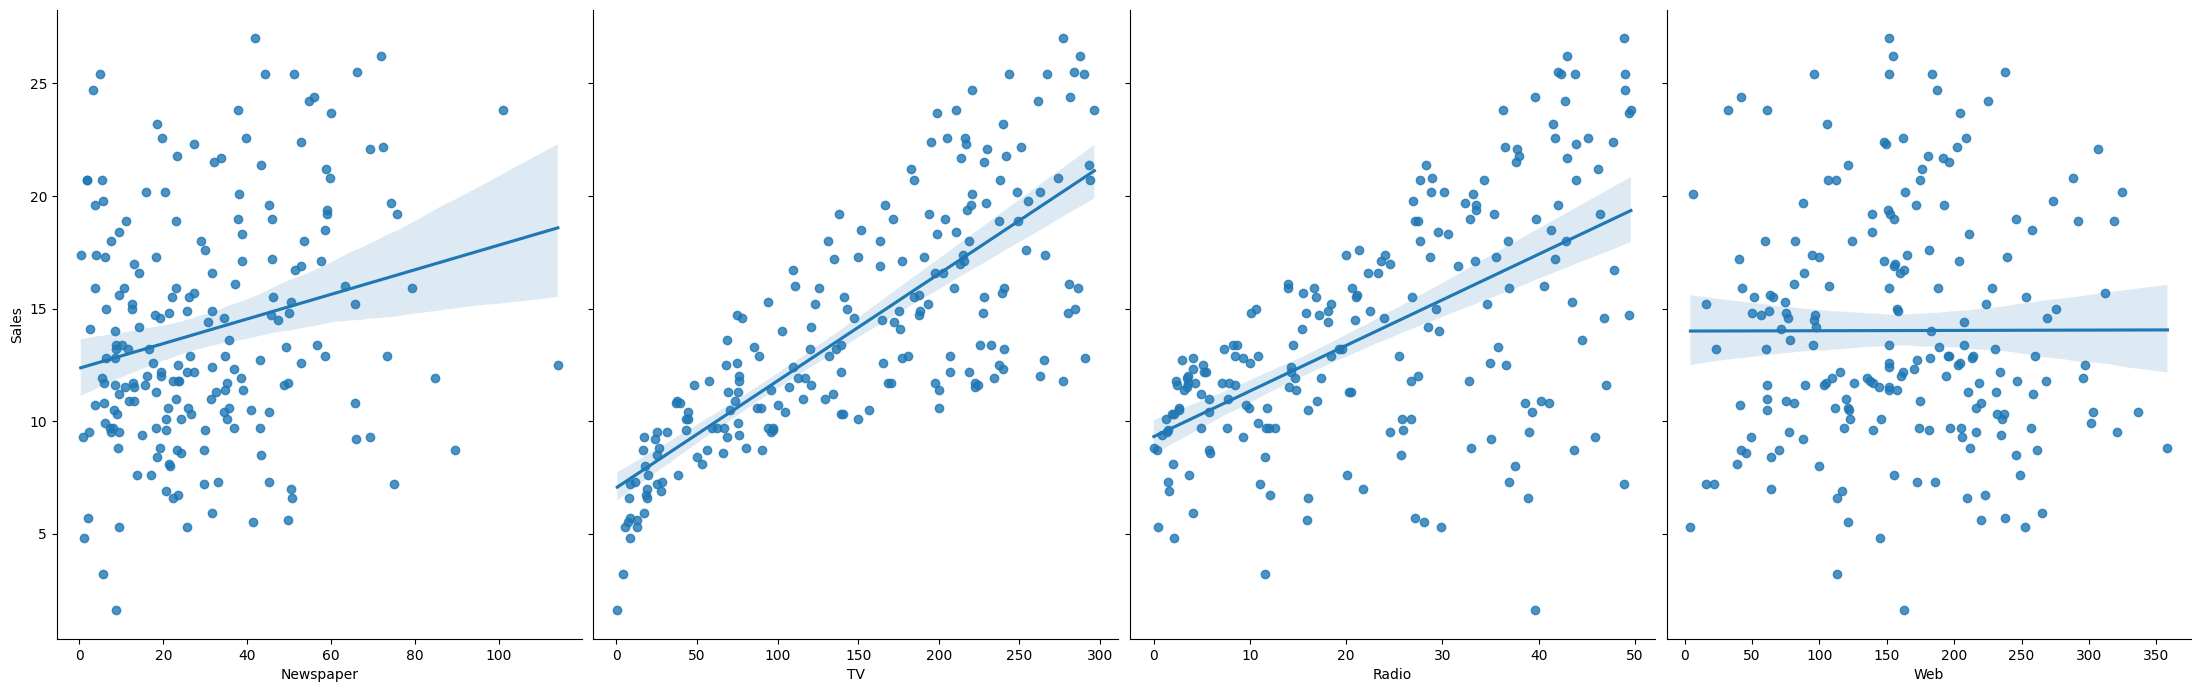

In [50]:
sns.pairplot(ventas,
             x_vars=['Newspaper','TV','Radio', 'Web'],
             y_vars='Sales',
             size=7,
             aspect=0.8,
             kind = 'reg')

calculamos las correlaciones de las variables

In [51]:
corr = ventas.corr()
corr

,Newspaper,TV,Radio,Web,Sales
Newspaper,1.000000,0.056648,0.354104,-0.057759,0.228299
TV,0.056648,1.000000,0.054809,0.012576,0.782224
Radio,0.354104,0.054809,1.000000,-0.122673,0.576223
Web,-0.057759,0.012576,-0.122673,1.000000,0.002108
Sales,0.228299,0.782224,0.576223,0.002108,1.000000


<Axes: >

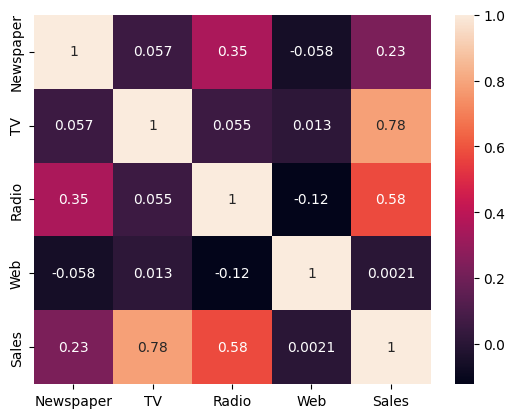

In [52]:
# matriz de correlación
sns.heatmap(corr, annot = True,
            yticklabels=corr.columns,
            xticklabels=corr.columns)

De los gráficos de dispersión y la matriz de correlación se puede identificar cuáles variables guardan una mayor relación con las ventas. Por ejemplo, *newspaper* tal vez tenga poco impacto en las ventas esto por la alta dispersión de los datos. Pero *TV* tiene un fuerte incidencia.

In [53]:
# variable objetivo
y = ventas['Sales']
# variables predictoras
X = ventas.drop('Sales', axis=1)
# conjunto de entrenamiento y prueba
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               train_size=.70,
                                               random_state=123)
# definimos el modelo
modelo = LinearRegression()
# entrenamo el modelo
modelo.fit(X_train,y_train)

LinearRegression()

In [54]:
print(modelo.intercept_)
print(modelo.coef_)

2.3456490843234192
[0.00387273 0.04574004 0.1876958  0.00270071]


Esto indica que:

$Sales = 2.34+0.003*Newspaper+ 0.045*TV+0.18*Radio+0.002*Web$

In [55]:
# predicciones en entrenamiento
y_pred_train=modelo.predict(X_train)
# predicciones en prueba
y_pred_test=modelo.predict(X_test)
print("R2 entrenamiento:",r2_score(y_train, y_pred_train))
print("R2 prueba:",r2_score(y_test, y_pred_test))
print("MSE entrenamiento:", mean_squared_error(y_train, y_pred_train))
print("MSE prueba:",  mean_squared_error(y_test, y_pred_test))
print("RMSE entrenamiento:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("RMSE prueba:",  np.sqrt(mean_squared_error(y_test, y_pred_test)))

R2 entrenamiento: 0.894958520024892
R2 prueba: 0.9103361643399669
MSE entrenamiento: 2.81904423412835
MSE prueba: 2.4604912172328266
RMSE entrenamiento: 1.6790009631112037
RMSE prueba: 1.5685953006536857


In [56]:
# calcular métricas básicas
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
# estadísticas de la variable objetivo
y_mean = ventas['Sales'].mean()
y_std = ventas['Sales'].std()
y_min = ventas['Sales'].min()
y_max = ventas['Sales'].max()
y_range = y_max - y_min

# comparaciones relativas
rmse_vs_mean = rmse / y_mean
rmse_vs_std = rmse / y_std
rmse_vs_range = rmse / y_range

nombre  = ["rmse", "media", "std", "min" , "max" , "rango"]
valores = [rmse, y_mean, y_std, y_min, y_max, y_range]
proporcion = ["",rmse_vs_mean, rmse_vs_std, "" , "", rmse_vs_range ]

pd.DataFrame({"nombre": nombre, "valor": valores, "proporcion": proporcion})

,nombre,valor,proporcion
0,rmse,1.568595,
1,media,14.022500,0.111863
2,std,5.217457,0.300644
3,min,1.600000,
4,max,27.000000,
5,rango,25.400000,0.061756


## <FONT SIZE=4 COLOR="blue"> 5.1 Ejercicios — Regresión Lineal Múltiple </FONT>

### <FONT SIZE=3 COLOR="blue"> Ejercicio 1 </FONT>
Si en tu modelo de regresión múltiple para precios de apartamentos, el coeficiente ($\beta$) de la variable `numero_de_banos` es positivo y muy grande, pero el de la variable `distancia_al_botadero_de_basura` es negativo. ¿Qué interpretación de negocio le das a estos signos matemáticos?


*Escribe tu respuesta aquí:*


### <FONT SIZE=3 COLOR="blue"> Ejercicio 2 </FONT>
¿Crees que es una buena idea introducir absolutamente TODAS las variables disponibles en un modelo de regresión múltiple? ¿Qué pasaría si introducimos variables que no tienen ninguna relación lógica con el precio (ej. color del piso)? Reflexiona sobre el concepto de "ruido".


*Escribe tu respuesta aquí:*

### <FONT SIZE=3 COLOR="blue"> Ejercicio 3 </FONT>
Vamos a entrenar un modelo Múltiple. Seleccionaremos varias columnas numéricas de nuestro dataframe `aptos` para predecir el `precio`. Compara el $R^2$ de este modelo con el del modelo simple que entrenamos arriba. ¿Mejoró?

In [57]:
# Variables múltiples (X) y objetivo (y)
X_mult = aptos[['mt2', 'estrato', 'alcobas', 'banos', 'administracion', 'avaluo']]
y_mult = aptos['precio']

# Dividimos los datos
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mult, y_mult, random_state=1, test_size=0.2)

# TU CÓDIGO AQUÍ:
# 1. Instancia el modelo LinearRegression()
modelo_multiple = ...

# 2. Entrénalo con X_train_m y y_train_m


# 3. Haz predicciones sobre X_test_m
y_pred_m = ...

# 4. Calcula e imprime el r2_score
r2_multiple = ...
print("El R2 del modelo Múltiple es:", r2_multiple)

El R2 del modelo Múltiple es: Ellipsis
